# Rung 5 — Walter becomes a GPT

**The question this notebook answers:** what *is* a GPT, once you've built every piece of it yourself?

Rung 4 ended with a clear diagnosis. Attention **gathers** information from earlier letters, but Walter had almost nothing to **think** with afterwards, so he couldn't beat Rung 3's MLP. A GPT is the fix, and it has surprisingly few parts:

1. **Attention** (Rung 4) to gather
2. **An MLP** (Rung 3) to think
3. **Stack** that pair several times, so later layers can build on what earlier ones found
4. **Residual connections** and **layer normalisation**, the plumbing that lets a deep stack train at all

That's it. GPT-2, GPT-4 and Claude are this same recipe, scaled up enormously and trained on far more text.

The code lives in [`walter_gpt.py`](walter_gpt.py), so that Rung 6 can open up exactly the same Walter. This notebook prints each piece as we reach it.

In [1]:
import inspect
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

import walter_gpt as wg

def show(obj):
    display(Markdown('```python\n' + inspect.getsource(obj) + '```'))

names = wg.Names()
print('vocabulary', names.vocab_size, '| positions', names.block_size,
      '| names: train', len(names.words['train']), 'dev', len(names.words['dev']), 'test', len(names.words['test']))
print('same split as Rungs 3 and 4, first training name:', names.words['train'][0])

vocabulary 27 | positions 16 | names: train 25626 dev 3203 test 3204
same split as Rungs 3 and 4, first training name: yuheng


## Step 1 — Attention, all heads at once

This is Rung 4's multi-head attention with one change for speed: instead of looping over separate `Head` objects, all heads' queries, keys and values come out of a single matrix multiply and are split apart with `view`. The maths is identical.

Two additions are for Rung 6. `self.att` keeps the last attention pattern so we can look at it, and `self.head_mask` lets us switch individual heads off to test what they do.

In [2]:
show(wg.CausalSelfAttention)

```python
class CausalSelfAttention(nn.Module):
    """Rung 4's multi-head attention, with all heads computed in one batched matmul."""

    def __init__(self, cfg):
        super().__init__()
        self.n_head, self.head_size = cfg.n_head, cfg.n_embd // cfg.n_head
        self.qkv = nn.Linear(cfg.n_embd, 3 * cfg.n_embd, bias=False)   # query, key, value for every head at once
        self.proj = nn.Linear(cfg.n_embd, cfg.n_embd)                  # mixes the heads back together
        self.drop = nn.Dropout(cfg.dropout)
        self.register_buffer('mask', torch.tril(torch.ones(cfg.block_size, cfg.block_size)) == 0)
        # Interpretability handles (Rung 6): the last attention pattern, and a per-head
        # multiplier on each head's output (1 = normal, 0 = head switched off).
        self.att = None
        self.head_mask = torch.ones(cfg.n_head)

    def forward(self, x):
        B, T, C = x.shape
        q, k, v = self.qkv(x).split(C, dim=2)
        q, k, v = (t.view(B, T, self.n_head, self.head_size).transpose(1, 2) for t in (q, k, v))  # (B, heads, T, hs)
        scores = q @ k.transpose(-2, -1) / self.head_size ** 0.5
        scores = scores.masked_fill(self.mask[:T, :T], float('-inf'))
        att = F.softmax(scores, dim=-1)
        self.att = att.detach()
        out = self.drop(att) @ v                                   # (B, heads, T, hs)
        out = out * self.head_mask.view(1, -1, 1, 1)
        out = out.transpose(1, 2).contiguous().view(B, T, C)       # heads side by side again
        return self.drop(self.proj(out))
```

## Step 2 — The MLP: thinking at each position

After attention has gathered what it needs into a position, the MLP processes it. It's Rung 3's hidden layer again: expand to 4 × 64 = 256 neurons, apply a nonlinearity, and project back down to 64. **GELU** is a smoother cousin of `tanh` and ReLU that works better in deep networks.

The MLP looks at each position **on its own**. It never moves information between positions; only attention does that. Communication, then computation.

In [3]:
show(wg.MLP)

```python
class MLP(nn.Module):
    """The 'thinking' part: the same idea as Rung 3's hidden layer, applied at every position."""

    def __init__(self, cfg):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(cfg.n_embd, 4 * cfg.n_embd),
            nn.GELU(),
            nn.Linear(4 * cfg.n_embd, cfg.n_embd),
            nn.Dropout(cfg.dropout),
        )

    def forward(self, x):
        return self.net(x)
```

## Step 3 — The residual stream: why depth doesn't break

Stack many layers naively, as in `x = layer3(layer2(layer1(x)))`, and training falls apart. Every layer has to pass everything along perfectly, and gradients have to squeeze back through every layer to reach the bottom.

Residual connections change the picture. Each layer **adds** to a running vector instead of replacing it:

```
x = x + attention(x)
x = x + mlp(x)
```

Picture a stream running through the model, one 64-number vector per position: the **residual stream**. Each layer reads from the stream and writes a small update back into it. Nothing is ever forced through a bottleneck. If a layer has nothing useful to add it can write ≈ 0, and the gradient flows straight down the stream to every layer.

This picture matters beyond training. In interpretability, the residual stream is **the** central object: it's the shared workspace every component reads from and writes to. Rung 6 reads it directly.

## Step 4 — Layer normalisation: keeping the numbers tame

As layers keep adding into the stream, the vectors can drift to very large or very small sizes. **LayerNorm** rescales each position's vector to mean 0 and standard deviation 1 (then applies a learned scale and shift) before a layer reads it.

In [4]:
x = torch.tensor([[2.0, 40.0, -7.0, 13.0]])
ln = nn.LayerNorm(4)
print('before:', x.numpy(), '  mean', x.mean().item(), ' std', round(x.std(unbiased=False).item(), 2))
y = ln(x).detach()
print('after :', y.numpy().round(2), '  mean', round(y.mean().item(), 4), ' std', round(y.std(unbiased=False).item(), 2))

before: [[ 2. 40. -7. 13.]]   mean 12.0  std 17.65
after : [[-0.57  1.59 -1.08  0.06]]   mean -0.0  std 1.0


## Step 5 — A transformer block, and the whole GPT

A **block** is: normalise → attend → add to the stream, then normalise → MLP → add to the stream.

In [5]:
show(wg.Block)

```python
class Block(nn.Module):
    """One transformer block: gather (attention), then think (MLP).

    Each sub-layer reads a normalised copy of the residual stream and *adds* its
    result back to it, so information flows straight through the stack.
    """

    def __init__(self, cfg):
        super().__init__()
        self.ln1 = nn.LayerNorm(cfg.n_embd)
        self.attn = CausalSelfAttention(cfg)
        self.ln2 = nn.LayerNorm(cfg.n_embd)
        self.mlp = MLP(cfg)

    def forward(self, x):
        x = x + self.attn(self.ln1(x))
        x = x + self.mlp(self.ln2(x))
        return x
```

And a **GPT** is: letter embeddings + position embeddings (Rung 4) → a stack of blocks → one last LayerNorm → a linear layer to 27 logits → softmax (Rung 2).

There's also **dropout**: during training, each layer's output has 10% of its numbers randomly zeroed. Walter can't rely on any single neuron, which pushes him towards robust patterns rather than memorising names. Dropout is switched off when we evaluate or generate.

In [6]:
show(wg.GPT.forward)
cfg = wg.Config(vocab_size=names.vocab_size, block_size=names.block_size)
print(cfg)
torch.manual_seed(2026)
fresh = wg.GPT(cfg)
print(f'parameters: {fresh.num_params():,}')
X, Y = names.data['train']
print('loss before training:', round(wg.evaluate(fresh, X, Y), 4), '(uniform guessing 3.2958)')

```python
    def forward(self, idx, targets=None, return_residuals=False):
        T = idx.shape[1]
        x = self.drop(self.tok(idx) + self.pos(torch.arange(T, device=idx.device)))
        residuals = [x]
        for block in self.blocks:
            x = block(x)
            residuals.append(x)
        logits = self.lm_head(self.ln_f(x))
        loss = None
        if targets is not None:
            loss = F.cross_entropy(logits.view(-1, logits.size(-1)), targets.view(-1), ignore_index=-1)
        if return_residuals:
            return logits, loss, residuals
        return logits, loss
```

Config(vocab_size=27, block_size=16, n_layer=4, n_head=4, n_embd=64, dropout=0.1)
parameters: 203,803


loss before training: 3.3005 (uniform guessing 3.2958)


About 200,000 parameters, against 729 in Rung 1 and 12,000 in Rung 3. For scale, GPT-2 small has 124 million, and today's frontier models have hundreds of billions. Walter's architecture is the same as theirs. What differs is size and data.

As in Rung 3, Walter starts humble: weights are initialised small, so his first guesses are close to uniform.

## Step 6 — Training

The training loop is Rung 4's, plus three standard pieces of craft (see `train` in `walter_gpt.py`):

- **Weight decay**: Rung 2's regularisation, pulling big weight matrices gently towards zero.
- **A learning-rate schedule**: a short warm-up, then the rate glides down along a cosine curve. This is Rung 3's "big steps, then small steps", made smooth.
- **Gradient clipping**: if one unlucky batch produces a huge gradient, it's scaled down so a single step can't wreck training.

20,000 steps of 64 names each. On a laptop CPU this takes roughly 10 minutes.

step      0/20000  train 3.2999  dev 3.2989


step   2000/20000  train 2.1118  dev 2.1294


step   4000/20000  train 2.0390  dev 2.0692


step   6000/20000  train 1.9828  dev 2.0330


step   8000/20000  train 1.9418  dev 2.0118


...

step  12000/20000  train 1.8783  dev 1.9790


step  14000/20000  train 1.8526  dev 1.9674


step  16000/20000  train 1.8341  dev 1.9596


step  18000/20000  train 1.8217  dev 1.9535


step  19999/20000  train 1.8112  dev 1.9495


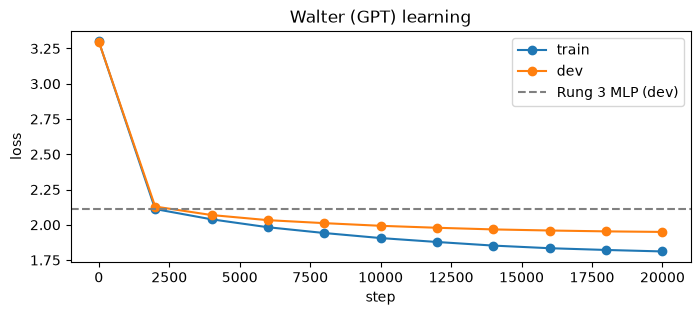

In [7]:
walter, history = wg.train(names)
steps, tr, dv = zip(*history)
plt.figure(figsize=(8, 3))
plt.plot(steps, tr, 'o-', label='train')
plt.plot(steps, dv, 'o-', label='dev')
plt.axhline(2.1136, color='gray', ls='--', label='Rung 3 MLP (dev)')
plt.xlabel('step'); plt.ylabel('loss'); plt.legend(); plt.title('Walter (GPT) learning')
plt.show()

## Step 7 — The whole climb in one table

Every rung, scored on the same dev names it never trained on, and finally, once, on the test names.

In [8]:
Xdev, Ydev = names.data['dev']
Xte, Yte = names.data['test']
gpt_dev, gpt_test = wg.evaluate(walter, Xdev, Ydev), wg.evaluate(walter, Xte, Yte)
rows = [('uniform guessing', 3.2958), ('Rung 1-2  bigram', 2.4533), ('Rung 3    MLP, 3 letters', 2.1136),
        ('Rung 4    attention, 4 heads', 2.1467), ('Rung 5    GPT', gpt_dev)]
print(f'{"model":32s} dev loss')
for name, loss in rows:
    print(f'{name:32s} {loss:.4f}  ' + '█' * int((3.4 - loss) * 30))
print(f'\nGPT test loss (touched once): {gpt_test:.4f}')

model                            dev loss
uniform guessing                 3.2958  ███
Rung 1-2  bigram                 2.4533  ████████████████████████████
Rung 3    MLP, 3 letters         2.1136  ██████████████████████████████████████
Rung 4    attention, 4 heads     2.1467  █████████████████████████████████████
Rung 5    GPT                    1.9495  ███████████████████████████████████████████

GPT test loss (touched once): 1.9472


Walter the GPT scores about **1.95** on names he has never seen, the biggest single improvement on the ladder after the jump from guessing to counting. Rung 4's diagnosis was right: gathering (attention) plus thinking (MLP), stacked, beats either alone.

Two more things are worth checking in the training curve and the numbers above:

- **Test ≈ dev.** We never tuned anything on the test names, and Walter does just as well on them, so the dev score wasn't a lucky fit to the dev set.
- **Train is below dev** (about 1.81 vs 1.95). Walter is starting to memorise some training names. With 200k parameters and only 25,000 names this is expected, and it's what dropout and weight decay are holding back.

## Step 8 — Walter speaks

Is Walter inventing, or reciting? We generate 500 names and check how many already exist in the training set.

In [9]:
samples = walter.generate(500, names)
train_set = set(names.words['train'])
all_names = set(names.words['train'] + names.words['dev'] + names.words['test'])
print('\n'.join(f'{s:16s}' + ('' if s in all_names else '(new)') for s in samples[:25]))
print(f'\n{sum(s not in train_set for s in samples) / len(samples):.0%} of 500 generated names are not in the training set')

sorbido         (new)
hadib           (new)
janovin         (new)
zephraine       (new)
ason            
ajanuin         (new)
acee            (new)
tavionna        (new)
bayal           (new)
marzah          (new)
nati            (new)
della           
mosemia         (new)
novali          
mattis          
jayde           
hasson          (new)
helem           
kynda           (new)
talil           (new)
kaxten          (new)
omberry         (new)
konbertan       (new)
imas            (new)
beson           (new)

73% of 500 generated names are not in the training set


Roughly three out of four generated names are inventions. The rest are real names, which is fine: a good model of names *should* sometimes produce `della` or `jayde`, because they're likely names. A model that only recited would be memorising. One that never produced a real name would have learned something other than names.

## Step 9 — How surprised is Walter?

Back to the last cell of Rung 1: the average surprise (loss) for a few names, now from the bigram table *and* from the GPT. Lower means "that looks like a name to me".

In [10]:
Xall, Yall = names.data['train']
N = torch.zeros((27, 27))
keep = Yall != -1
N.index_put_((Xall[keep], Yall[keep]), torch.ones(int(keep.sum())), accumulate=True)
P = (N + 1) / (N + 1).sum(1, keepdim=True)

print(f'{"name":12s} bigram   GPT')
for name in ['constantin', 'walter', 'anthropic', 'irakoze', 'xqzv']:
    x, y = names.encode(name), torch.tensor([[names.stoi[c] for c in name] + [0]])
    bigram = -P[x[0], y[0]].log().mean().item()
    gpt = wg.evaluate(walter, x, y)
    print(f'{name:12s} {bigram:6.2f}  {gpt:5.2f}')

name         bigram   GPT
constantin     2.35   1.17
walter         2.89   1.84
anthropic      3.04   3.36
irakoze        2.98   3.84
xqzv           5.45   7.27


There's a lot in this little table:

- **`constantin` and `walter` look very name-like to the GPT** (1.17 and 1.84, far below the bigram). Both are in the training list, and the GPT has the capacity to remember them, while the bigram only knows letter pairs.
- **`xqzv` and `anthropic` surprise the GPT *more* than the bigram.** The GPT is more confident, so when a string breaks its expectations it's more surprised. Sharper beliefs mean bigger surprises.
- **`irakoze` surprises the GPT more than the bigram does.** `names.txt` comes from US birth records, so Kinyarwanda names are almost absent. A sharper model of *this* list is also a narrower one: Walter has learned "names in this dataset", not "names". The data decides what a model treats as normal, and that's as true for large language models as it is for Walter.

## Step 10 — Save Walter for Rung 6

In [11]:
wg.save(walter)
print('saved to', wg.CHECKPOINT_PATH)

saved to /home/user/Noesis/rung5_gpt/walter_gpt.pt


## What just happened

1. **Attention** gathers information between positions; the **MLP** computes with it at each position.
2. A **block** is attention then MLP, each reading a **LayerNorm**ed copy of the stream and **adding** its result back.
3. The **residual stream** is the shared workspace that runs through the whole model, which is what makes depth trainable.
4. **Stacking 4 blocks** with 4 heads each gave a ~200k-parameter GPT, the same architecture as the models that write essays, at toy scale.
5. Walter now beats every earlier rung on names he has never seen, and he mostly **invents** rather than recites.

The question from Rung 1, *how does text become mathematics, and how does that mathematics predict what comes next?*, now has a full answer for one small model. Letters become IDs, IDs become vectors, vectors flow up a residual stream where attention and MLPs refine them, and a final softmax turns the result into a probability for every possible next letter. Every number in it was learned by walking downhill on the loss from Rung 1.

What we *don't* yet know is what Walter actually does with all that machinery. That's the rest of the climb.

## Your turn (do these before Rung 6)
- Train with `n_layer=1`, then `n_layer=8` (pass `cfg=wg.Config(..., n_layer=...)` to `wg.train`). Does depth help names?
- Set `dropout=0.0`. Does the gap between train and dev loss grow?
- Generate with `temperature=0.5` and then `1.5`. What changes, and why? (Hint: what does dividing logits by a number do to the softmax?)
- Remove the residual connections in `Block` (`x = self.attn(self.ln1(x))`) and retrain. What happens?

**Next — Rung 6:** we open Walter up. Which heads matter? What do they look at? How does his prediction take shape layer by layer?